<div align="center"> 

# Gini Regressions

## [S. Mussard](https://sites.google.com/view/cv-stphane-mussard/accueil "Homepage")

</div>

<div align="center"> 
<a href="http://scikit-learn.org/stable/#"><img src="http://scikit-learn.org/stable/_static/scikit-learn-logo-small.png" style="max-width: 180px; display: inline" alt="Scikit-Learn"/></a>
</div>

In [1]:
#!pip install outliers
#!pip install outlier_utils
#!pip install iteration_utilities

In [2]:
from datetime import datetime
from scipy.stats import norm
from statsmodels.iolib.table import SimpleTable
from statsmodels.compat.python import lrange
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
import torch
from datetime import datetime
from scipy.stats import norm
from statsmodels.iolib.table import SimpleTable
from statsmodels.compat.python import lrange
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
try:
    from OUTLIERS import smirnov_grubbs as grubbs
except ImportError:
    from outliers import smirnov_grubbs as grubbs
from sklearn.model_selection import train_test_split
from numpy.linalg import inv
from numpy.linalg import pinv
from scipy import linalg
from sklearn.metrics import confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.optimize import minimize
import warnings
from sklearn.model_selection import train_test_split
from numpy.linalg import inv
from numpy.linalg import pinv
from scipy import linalg
from sklearn.metrics import confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.optimize import minimize
import warnings

In [3]:
df = pd.read_excel("natality.xlsx")
df.columns

Index(['department_number', 'department', 'POP_1999', 'POP_2012', 'size_DEPT',
       'growth_pop', 'natality_rate', 'foreigners', 'immigrants', 'imm_EU',
       'imm_mag', 'imm_other', 'male', 'female', 'more_60years',
       'reception_facilities', 'poverty_rate'],
      dtype='object')

In [4]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
df = pd.read_excel("natality.xlsx")
y = df["natality_rate"]
X = df[["poverty_rate", "imm_mag", "reception_facilities", "foreigners", "growth_pop"]]
X_ones = sm.add_constant(X)
# OLS model
model_ols = sm.OLS(y, X_ones)
ols_results = model_ols.fit()
# Breusch-Pagan test
bp_test = sm.stats.diagnostic.het_breuschpagan(ols_results.resid, X_ones)
print("Breusch-Pagan test p-value:", bp_test[1])
# White test 
white_test_result = het_white(ols_results.resid, exog=X_ones)
print("White Test (LM-Test) p-value:", np.round(white_test_result[1],4))

Breusch-Pagan test p-value: 2.9872883552496115e-05
White Test (LM-Test) p-value: 0.0


In [5]:
# Correlation between natality and poverty
np.corrcoef(df["natality_rate"].T,df["poverty_rate"].T)[0][1] 
np.corrcoef(df["natality_rate"].T,df["growth_pop"].T)[0][1] 

0.20767005428187413

In [6]:
X.head()

,poverty_rate,imm_mag,reception_facilities,foreigners,growth_pop
0,11.0,28.8,106.2,49612,18.809750
1,18.7,37.6,36.0,13741,1.008237
2,15.5,25.6,73.6,9668,-0.525062
3,15.9,30.9,211.1,7102,15.534426
4,14.0,26.3,186.0,4807,14.935883


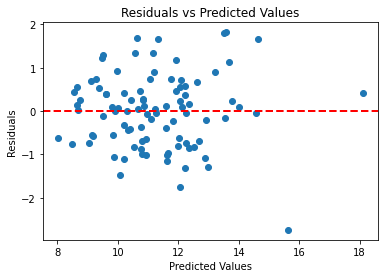

In [7]:
# Plot residuals against predicted values
plt.scatter(ols_results.predict(X_ones), ols_results.resid)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [8]:
# FGRR non-parametric 
from GiniRegression_v2 import GiniRegression
from GiniRegression_v2 import Hetero
model = Hetero(GiniRegression)
model.fit(y, X, hetero = 'FGGR') # 
model.summary()

                                   Gini Regression                                   
Dep. Variable:                         y     Gini R-squared:                   0.8313
Model:                   Gini Regression     Adj. Gini R-squared:              0.8197
Method:                   Non Parametric     U-stat (Gini R2):                 20.104
Jackknife iterations                  94     Prob (U-stat):                       0.0
Date:                   Sat, 27 Sep 2025     No. Outliers in x:                     5
Time:                           12:35:41     Df Residuals:                         87
Covariance type:                   False     No. Observations:                     94
                             Coefficients * and * Tests                            
 Variables   Coeff   Std err     U     P>|U|   [0.025   0.975]   VIF Gini  VIF OLS 
-----------------------------------------------------------------------------------
  Intercept 10.0047    1.8038  5.5465     0.0   6.4693  13.5

In [9]:
# Parametric Gini regression
model = GiniRegression()
model.fit(y, X, parametric_estimator = True) # 
model.summary()

c:\Users\smussa01\Documents\Python Scripts\Book Gini\reg hetero\GiniRegression_v2.py:184: UserWarning: If no cov method is invoked then the non-parametric cov is used
  warnings.warn("If no cov method is invoked then the non-parametric cov is used", UserWarning)


                                   Gini Regression                                   
Dep. Variable:                         y     Gini R-squared:                   0.7916
Model:                   Gini Regression     Adj. Gini R-squared:              0.7772
Method:                       Parametric     U-stat (Gini R2):                11.4411
Jackknife iterations                  94     Prob (U-stat):                       0.0
Date:                   Sat, 27 Sep 2025     No. Outliers in x:                     5
Time:                           12:35:41     Df Residuals:                         87
Covariance type:                   False     No. Observations:                     94
                                 Coefficients * and * Tests                                 
     Variables        Coeff   Std err     U     P>|U|   [0.025   0.975]   VIF Gini  VIF OLS 
--------------------------------------------------------------------------------------------
           Intercept     0.0     

In [10]:
# GLS model
cov_matrix = np.diag(ols_results.resid**2)
gls_model = sm.GLS(y, X_ones, sigma=cov_matrix)
gls_results = gls_model.fit()
print(gls_results.summary())

                            GLS Regression Results                            
Dep. Variable:          natality_rate   R-squared:                       0.996
Model:                            GLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     4290.
Date:                Sat, 27 Sep 2025   Prob (F-statistic):          1.79e-103
Time:                        12:35:41   Log-Likelihood:                -47.873
No. Observations:                  94   AIC:                             107.7
Df Residuals:                      88   BIC:                             123.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.4833 

In [11]:
# Perform the Breusch-Pagan test
bp_test = sm.stats.diagnostic.het_breuschpagan(gls_results.resid, X_ones)
print("Breusch-Pagan test p-value:", bp_test[1])
# White
white_test_result = het_white(gls_results.resid, exog=X_ones)
print("White Test Results:")
print("LM Statistic:", white_test_result[0])
print("LM-Test p-value:", white_test_result[1])
print("F-Test p-value:", white_test_result[2])

Breusch-Pagan test p-value: 1.8886916010495942e-05
White Test Results:
LM Statistic: 55.827198567202494
LM-Test p-value: 3.086243221821294e-05
F-Test p-value: 5.338074941369474


In [12]:
# Test resids Gini model
model = Hetero(GiniRegression)
model.fit(y, X, hetero = 'FGGR') # 
beta = model.summary(get_coeff=True)
resids_gini = y - X_ones@beta 
# Perform the Breusch-Pagan test
bp_test = sm.stats.diagnostic.het_breuschpagan(resids_gini, X_ones)
print("Breusch-Pagan test p-value:", bp_test[1])
# White
white_test_result = het_white(resids_gini, exog=X_ones)
print("White Test Results:")
print("LM Statistic:", white_test_result[0])
print("LM-Test p-value:", white_test_result[1])
print("F-Test p-value:", white_test_result[2])

Breusch-Pagan test p-value: 1.0562836727616308e-05
White Test Results:
LM Statistic: 65.37159871342047
LM-Test p-value: 1.0182072948084682e-06
F-Test p-value: 8.334602163615717
